In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
PREDSDIR  = CONFIGS['filepaths']['predictions']
MODELS    = CONFIGS['experiments']
SPLIT     = 'test'

_nn    = MODELS['nn']['runs']
_sropt = MODELS['sr']['optimizedeqs']
MODELDICT = {
    'pod_bl':      {'label':'POD-BL',                          'color':'k',                          'marker':'x'},
    'nn_bl':       {'label':_nn['nn_bl']['description'],       'color':_nn['nn_bl']['color'],        'marker':'D'},
    'nn_full':     {'label':_nn['nn_full']['description'],     'color':_nn['nn_full']['color'],      'marker':'D'},
    'nn_nonparam': {'label':_nn['nn_nonparam']['description'], 'color':_nn['nn_nonparam']['color'],  'marker':'D'},
    'nn_gauss':    {'label':_nn['nn_gauss']['description'],    'color':_nn['nn_gauss']['color'],     'marker':'D'},
    'sr_bl':       {'label':_sropt['sr_bl']['description'],    'color':_sropt['sr_bl']['color'],     'marker':'o'},
    'sr_lo':       {'label':_sropt['sr_lo']['description'],    'color':_sropt['sr_lo']['color'],     'marker':'o'},
    'sr_med':      {'label':_sropt['sr_med']['description'],   'color':_sropt['sr_med']['color'],    'marker':'o'},
    'sr_hi':       {'label':_sropt['sr_hi']['description'],    'color':_sropt['sr_hi']['color'],     'marker':'o'},
}

In [4]:
def get_r2(ytrue, ypred, dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    ssres = ((ytrue-ypred)**2).sum(dim=dims, skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims, skipna=True))**2).sum(dim=dims, skipna=True)
    return float(1-ssres/sstot)

def get_mse(ytrue, ypred, dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    return float(((ytrue-ypred)**2).mean(dim=dims, skipna=True))

def get_nn_complexity(kind, nfieldvars, nlevs, nlocalvars):
    def nparams(nfeatures):
        return (nfeatures*256)+256+(256*128)+128+(128*64)+64+(64*32)+32+(32*1)+1
    if kind == 'baseline':      return nparams(nfieldvars*nlevs+nlocalvars)
    if kind == 'nonparametric': return nfieldvars*nlevs+nparams(nfieldvars+nlocalvars)
    if kind == 'parametric':    return 2*nfieldvars+nparams(nfieldvars+nlocalvars)

def get_mse_at_r2(ytrue, r2_target=0.5, dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    sstot = ((ytrue-ytrue.mean(dim=dims, skipna=True))**2).sum(dim=dims, skipna=True)
    return float((1-r2_target)*sstot/ytrue.count(dim=dims))

def pareto_front(records):
    ordered, front, best = sorted(records, key=lambda r: r['mse']), [], np.inf
    for r in ordered:
        if r['nparams'] < best:
            front.append(r)
            best = r['nparams']
    return sorted(front, key=lambda r: r['nparams'])

In [7]:
with xr.open_dataset(os.path.join(SPLITSDIR, f'{SPLIT}.h5'), engine='h5netcdf') as ds:
    truetp = ds.tp.load()

with xr.open_dataset(os.path.join(SPLITSDIR, 'norm_train.h5'), engine='h5netcdf') as ds:
    firstvar = next(iter(MODELS['nn']['runs'].values()))['fieldvars'][0]
    nsigs    = ds.sizes['sig'] if 'sig' in ds[firstvar].dims else 1

def get_target_nparams(name):
    if name == 'pod_bl':
        with np.load(os.path.join(MODELSDIR, 'pod', f'{name}.npz')) as d:
            return int(d['nparams'])
    if name in MODELS['nn']['runs']:
        cfg = MODELS['nn']['runs'][name]
        return get_nn_complexity(cfg['kind'], len(cfg['fieldvars']), nsigs, len(cfg.get('localvars', [])))
    if name in MODELS['sr'].get('optimizedeqs', {}):
        return MODELS['sr']['optimizedeqs'][name]['refcomplexity']

targetresults = {}
for name in MODELDICT:
    path = os.path.join(PREDSDIR, f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(path):
        print(f'Missing: {name}')
        continue
    with xr.open_dataset(path) as ds:
        pred = ds.tp.load()
    if 'seed' in pred.dims:       pred = pred.mean('seed')
    if 'complexity' in pred.dims: pred = pred.isel(complexity=0)
    ytrue, ypred = xr.align(truetp, pred, join='inner')
    targetresults[name] = (ytrue.squeeze(), ypred.squeeze())

targetr2seeds = {}
for name in MODELDICT:
    if name not in targetresults: continue
    path = os.path.join(PREDSDIR, f'{name}_{SPLIT}_predictions.nc')
    with xr.open_dataset(path) as ds:
        pred = ds.tp.load()
    if 'seed' not in pred.dims or pred.sizes.get('seed', 1) < 2: continue
    ytrue = targetresults[name][0]
    targetr2seeds[name] = np.array([
        get_r2(ytrue, xr.align(truetp, pred.sel(seed=sid).squeeze(), join='inner')[1].squeeze())
        for sid in pred.seed.values])

# paretoresults = {}
# for name in MODELS['sr']['runs']:
#     path = os.path.join(PREDSDIR, f'{name}_{SPLIT}_predictions.nc')
#     if not os.path.exists(path): continue
#     with xr.open_dataset(path) as ds:
#         pred = ds.tp.load()
#     if 'seed' in pred.dims:        pred = pred.mean('seed')
#     if 'complexity' not in pred.dims: continue
#     ytrue, ypred = xr.align(truetp, pred, join='inner')
#     paretoresults[name] = (ytrue.squeeze(), ypred.squeeze())

print(f'{len(targetresults)}/{len(MODELDICT)} target models loaded, {len(paretoresults)} Pareto runs loaded')

9/9 target models loaded, 0 Pareto runs loaded


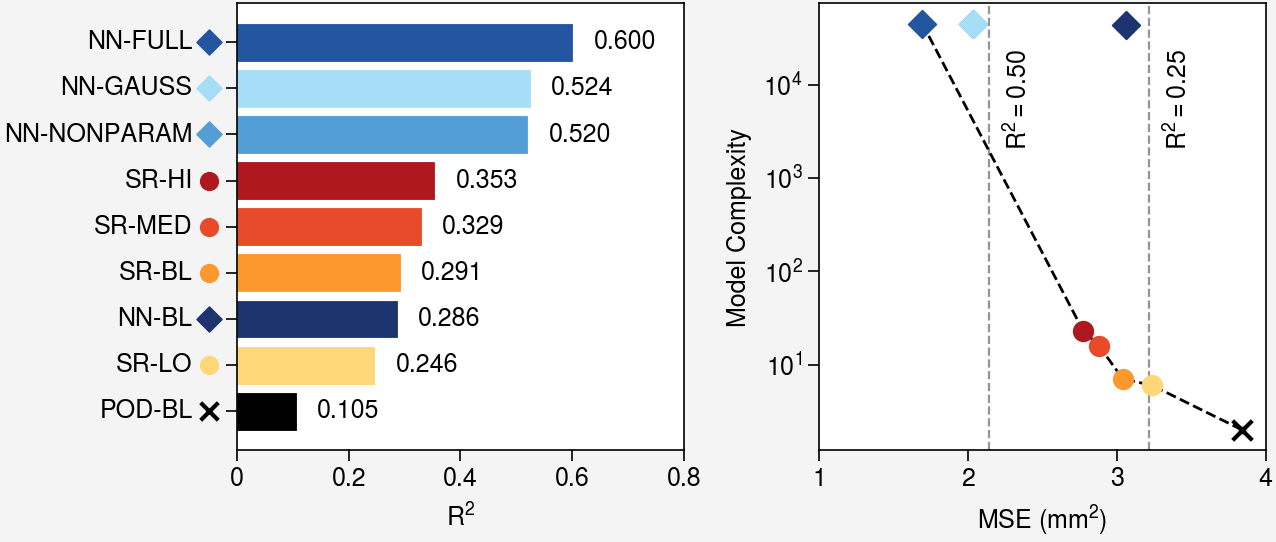

In [8]:
targetr2      = {n: float(targetr2seeds[n].mean()) if n in targetr2seeds else get_r2(*targetresults[n]) for n in targetresults}
targetmse     = {n: get_mse(*targetresults[n]) for n in targetresults}
targetnparams = {n: get_target_nparams(n) for n in targetresults}

frontierrecords = []
for run, (ytrue, ypred) in paretoresults.items():
    for c in ypred.complexity.values:
        frontierrecords.append(dict(mse=get_mse(ytrue, ypred.sel(complexity=int(c))), nparams=int(c)))
for name in MODELDICT:
    if name not in targetresults or targetnparams.get(name) is None: continue
    frontierrecords.append(dict(mse=targetmse[name], nparams=targetnparams[name]))
frontier = pareto_front(frontierrecords) if frontierrecords else []
mserefs  = {r2: get_mse_at_r2(next(iter(targetresults.values()))[0], r2_target=r2) for r2 in [0.25, 0.5]}

rows   = sorted([(n, targetr2[n]) for n in MODELDICT if n in targetr2], key=lambda x: x[1])
labels = [MODELDICT[n]['label'] for n, _ in rows]
colors = [MODELDICT[n]['color'] for n, _ in rows]
r2s    = [targetr2[n] for n, _ in rows]

fig, axs = pplt.subplots(ncols=2, figwidth=6.5, refwidth=2, share=False, tight=True)
axs[0].barh(labels, r2s, color=colors)
for i, (name, _) in enumerate(rows):
    info = MODELDICT[name]
    axs[0].scatter(-0.05, i, marker=info['marker'], color=info['color'], markersize=40, clip_on=False)
axs[0].set_yticks(range(len(labels)))
axs[0].set_yticklabels([])
for i, label in enumerate(labels):
    axs[0].text(-0.08, i, label, va='center', ha='right')
for i, (name, _) in enumerate(rows):
    axs[0].text(max(targetr2[name]+0.15, 0.01), i, f'{targetr2[name]:.3f}', va='center', ha='right')
axs[0].format(grid=False, xlabel=r'$R^2$', xlim=(0, 0.8))

if frontierrecords:
    axs[1].scatter([r['mse'] for r in frontierrecords], [r['nparams'] for r in frontierrecords],
                   color='gray', alpha=0.35, zorder=2, s=10)
    if len(frontier) > 1:
        axs[1].plot([r['mse'] for r in frontier], [r['nparams'] for r in frontier],
                    color='k', linestyle='--', lw=1, zorder=3)
for name, info in MODELDICT.items():
    if name not in targetresults or targetnparams.get(name) is None: continue
    axs[1].scatter(targetmse[name], targetnparams[name], color=info['color'], marker=info['marker'],
                   s=50, zorder=6, label=info['label'])
for r2, mse in mserefs.items():
    axs[1].axvline(mse, color='gray', linestyle='--', linewidth=0.8)
    axs[1].text(mse+0.1, 0.9, rf'$R^2={r2:.2f}$', rotation=90, va='top', ha='left',
                transform=axs[1].get_xaxis_transform())
axs[1].format(grid=False, xlabel=r'MSE (mm$^2$)', xlim=(1, 4),
              ylabel='Model Complexity', yscale='log', yformatter='log')
pplt.show()
fig.save('../figs/fig_1.jpg')